<a href="https://colab.research.google.com/github/jigar-shroff/AiOnDigitalMediaResearch/blob/main/AIOnDigitalMediaResearch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone "https://github.com/jigar-shroff/AiOnDigitalMediaResearch.git"

Cloning into 'AiOnDigitalMediaResearch'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 9 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 7.98 KiB | 7.98 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [7]:
aiFrame = pd.read_csv("AiOnDigitalMediaResearch/Global_AI_Content_Impact_Dataset.csv")
aiFrame

,Country,Year,Industry,AI Adoption Rate (%),AI-Generated Content Volume (TBs per year),Job Loss Due to AI (%),Revenue Increase Due to AI (%),Human-AI Collaboration Rate (%),Top AI Tools Used,Regulation Status,Consumer Trust in AI (%),Market Share of AI Companies (%)
0,South Korea,2022,Media,44.29,33.09,16.77,46.12,74.79,Bard,Strict,40.77,18.73
1,China,2025,Legal,34.75,66.74,46.89,52.46,26.17,DALL-E,Strict,35.67,35.02
2,USA,2022,Automotive,81.06,96.13,10.66,45.60,39.66,Stable Diffusion,Moderate,54.47,22.76
3,France,2021,Legal,85.24,93.76,27.70,78.24,29.45,Claude,Moderate,51.84,1.93
4,France,2021,Gaming,78.95,45.62,17.45,1.05,21.70,Midjourney,Strict,41.77,21.41
...,...,...,...,...,...,...,...,...,...,...,...,...
195,Germany,2021,Automotive,89.44,52.98,48.47,12.14,30.60,DALL-E,Lenient,77.21,44.35
196,Germany,2020,Media,70.11,28.26,27.62,57.86,58.71,DALL-E,Strict,78.74,31.73
197,France,2023,Marketing,65.77,49.83,39.94,79.44,43.73,Synthesia,Lenient,81.58,14.62
198,Australia,2023,Automotive,45.35,20.49,33.21,50.50,41.73,Claude,Strict,47.42,43.11


In [8]:
aiFrame.info() #no non-null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Country                                     200 non-null    object 
 1   Year                                        200 non-null    int64  
 2   Industry                                    200 non-null    object 
 3   AI Adoption Rate (%)                        200 non-null    float64
 4   AI-Generated Content Volume (TBs per year)  200 non-null    float64
 5   Job Loss Due to AI (%)                      200 non-null    float64
 6   Revenue Increase Due to AI (%)              200 non-null    float64
 7   Human-AI Collaboration Rate (%)             200 non-null    float64
 8   Top AI Tools Used                           200 non-null    object 
 9   Regulation Status                           200 non-null    object 
 10  Consumer Trust

In [9]:
aiFrame["Country"].value_counts()

,count
Country,
India,24
France,24
Japan,22
China,21
USA,21
South Korea,20
UK,20
Germany,17
Canada,16


Only Asia, N. Amer., Aus., and a small part of Eur. are represented w/ this data

In [29]:
#rename some columns

def removeParentheses(string):

  firstIndex = 0
  newString = string

  for r in range(len(string)):

    if(string[r] == "("):
      firstIndex = r
    elif(string[r] == ")"):
      newString = string[:firstIndex] + string[r+1:]

  return newString

print(aiFrame.columns)


for e in aiFrame.columns:

  aiFrame = aiFrame.rename(columns = {e: removeParentheses(e).strip()})

aiFrame


Index(['Country', 'Year', 'Industry', 'AI Adoption Rate ',
       'AI-Generated Content Volume ', 'Job Loss Due to AI ',
       'Revenue Increase Due to AI ', 'Human-AI Collaboration Rate ',
       'Top AI Tools Used', 'Regulation Status', 'Consumer Trust in AI ',
       'Market Share of AI Companies '],
      dtype='object')


,Country,Year,Industry,AI Adoption Rate,AI-Generated Content Volume,Job Loss Due to AI,Revenue Increase Due to AI,Human-AI Collaboration Rate,Top AI Tools Used,Regulation Status,Consumer Trust in AI,Market Share of AI Companies
0,South Korea,2022,Media,44.29,33.09,16.77,46.12,74.79,Bard,Strict,40.77,18.73
1,China,2025,Legal,34.75,66.74,46.89,52.46,26.17,DALL-E,Strict,35.67,35.02
2,USA,2022,Automotive,81.06,96.13,10.66,45.60,39.66,Stable Diffusion,Moderate,54.47,22.76
3,France,2021,Legal,85.24,93.76,27.70,78.24,29.45,Claude,Moderate,51.84,1.93
4,France,2021,Gaming,78.95,45.62,17.45,1.05,21.70,Midjourney,Strict,41.77,21.41
...,...,...,...,...,...,...,...,...,...,...,...,...
195,Germany,2021,Automotive,89.44,52.98,48.47,12.14,30.60,DALL-E,Lenient,77.21,44.35
196,Germany,2020,Media,70.11,28.26,27.62,57.86,58.71,DALL-E,Strict,78.74,31.73
197,France,2023,Marketing,65.77,49.83,39.94,79.44,43.73,Synthesia,Lenient,81.58,14.62
198,Australia,2023,Automotive,45.35,20.49,33.21,50.50,41.73,Claude,Strict,47.42,43.11


In [31]:
sortedByYear = aiFrame.sort_values(by = "Year", ascending = True)
sortedByYear

,Country,Year,Industry,AI Adoption Rate,AI-Generated Content Volume,Job Loss Due to AI,Revenue Increase Due to AI,Human-AI Collaboration Rate,Top AI Tools Used,Regulation Status,Consumer Trust in AI,Market Share of AI Companies
12,France,2020,Marketing,71.00,77.53,17.41,12.56,31.57,Midjourney,Strict,56.93,38.36
26,USA,2020,Retail,26.12,73.78,21.51,22.63,65.41,Midjourney,Strict,44.56,3.46
25,France,2020,Automotive,79.59,20.37,39.06,44.06,83.18,Synthesia,Moderate,45.04,14.03
46,France,2020,Media,20.47,1.61,2.43,31.04,52.49,Stable Diffusion,Strict,35.80,24.29
51,South Korea,2020,Automotive,30.94,82.97,37.08,60.61,56.01,Bard,Lenient,85.10,38.38
...,...,...,...,...,...,...,...,...,...,...,...,...
133,China,2025,Gaming,70.04,66.60,29.79,23.17,58.46,Bard,Moderate,41.08,8.39
143,India,2025,Retail,76.35,78.99,3.82,0.73,70.78,Stable Diffusion,Lenient,70.39,45.49
194,France,2025,Retail,29.61,59.56,24.68,46.92,57.21,DALL-E,Moderate,31.70,28.90
192,Canada,2025,Marketing,78.43,84.82,26.41,4.72,33.28,Synthesia,Moderate,64.49,45.04


In [46]:
#Figure out consumer confidence over last few years

countries = sortedByYear.groupby("Country")
usa = countries.get_group("USA")
usa

,Country,Year,Industry,AI Adoption Rate,AI-Generated Content Volume,Job Loss Due to AI,Revenue Increase Due to AI,Human-AI Collaboration Rate,Top AI Tools Used,Regulation Status,Consumer Trust in AI,Market Share of AI Companies
26,USA,2020,Retail,26.12,73.78,21.51,22.63,65.41,Midjourney,Strict,44.56,3.46
111,USA,2020,Media,27.50,23.67,2.21,56.52,60.77,Claude,Strict,36.75,12.56
189,USA,2020,Finance,36.52,4.20,25.53,71.01,21.92,Bard,Moderate,84.90,29.93
126,USA,2021,Marketing,56.81,56.52,15.98,69.17,51.21,Midjourney,Lenient,54.41,20.22
90,USA,2021,Gaming,67.18,7.92,40.55,52.54,50.30,Synthesia,Moderate,73.15,8.66
47,USA,2021,Manufacturing,83.40,66.33,24.27,34.95,47.21,Claude,Moderate,47.81,47.40
5,USA,2021,Retail,66.95,47.72,0.86,27.58,64.42,ChatGPT,Lenient,68.14,8.09
179,USA,2021,Education,87.79,40.86,28.82,74.04,70.58,Stable Diffusion,Strict,60.03,12.22
146,USA,2021,Education,73.11,98.77,38.22,67.17,87.65,Synthesia,Lenient,31.54,31.14
38,USA,2022,Manufacturing,44.61,26.16,49.34,58.53,75.29,Stable Diffusion,Moderate,32.96,43.24


In [34]:
americaByYears = []

for r in range(2020, 2026, 1):
  americaByYears.append(usa.groupby("Year").get_group(r))



In [25]:
#the length of all the dataframes in the array are not equal to each other
#also there are duplicate industries??? Is that right??

,Country,Year,Industry,AI Adoption Rate,AI-Generated Content Volume,Job Loss Due to AI,Revenue Increase Due to AI,Human-AI Collaboration Rate,Top AI Tools Used,Regulation Status,Consumer Trust in AI,Market Share of AI Companies
126,USA,2021,Marketing,56.81,56.52,15.98,69.17,51.21,Midjourney,Lenient,54.41,20.22
90,USA,2021,Gaming,67.18,7.92,40.55,52.54,50.30,Synthesia,Moderate,73.15,8.66
47,USA,2021,Manufacturing,83.40,66.33,24.27,34.95,47.21,Claude,Moderate,47.81,47.40
5,USA,2021,Retail,66.95,47.72,0.86,27.58,64.42,ChatGPT,Lenient,68.14,8.09
179,USA,2021,Education,87.79,40.86,28.82,74.04,70.58,Stable Diffusion,Strict,60.03,12.22
146,USA,2021,Education,73.11,98.77,38.22,67.17,87.65,Synthesia,Lenient,31.54,31.14


In [38]:
usaMeans = [] #stores the mean of each year

for df in americaByYears:
  usaMeans.append(df["Consumer Trust in AI"].mean())

print(usaMeans)

[np.float64(55.403333333333336), np.float64(55.846666666666664), np.float64(44.92333333333334), np.float64(70.965), np.float64(60.99), np.float64(56.883333333333326)]


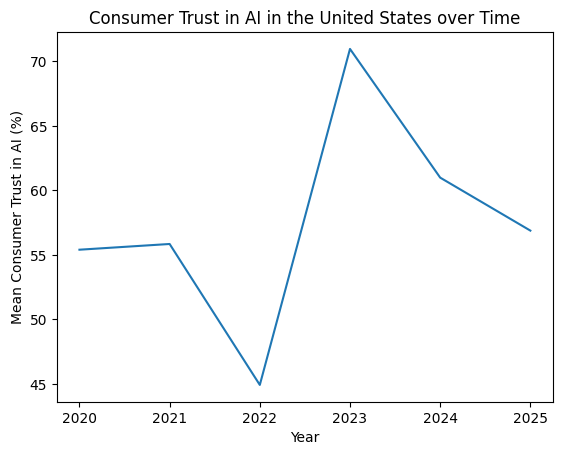

In [43]:
years = [2020, 2021, 2022, 2023, 2024, 2025]

plt.plot(years, usaMeans)

plt.title("Consumer Trust in AI in the United States over Time")
plt.xlabel("Year")
plt.ylabel("Mean Consumer Trust in AI (%)")

plt.show()

[np.float64(58.791999999999994), np.float64(54.16), np.float64(72.87), np.float64(39.63), np.float64(58.078333333333326), np.float64(62.73375)]


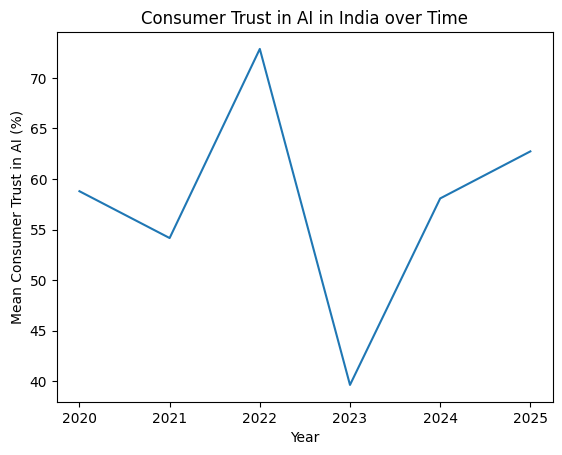

In [44]:
indiaByYears = []

for r in range(2020, 2026, 1):
  indiaByYears.append(countries.get_group("India").groupby("Year").get_group(r))

indiaMeans = []

for df in indiaByYears:
  indiaMeans.append(df["Consumer Trust in AI"].mean())

print(indiaMeans)

plt.plot(years, indiaMeans)
plt.title("Consumer Trust in AI in India over Time")
plt.xlabel("Year")
plt.ylabel("Mean Consumer Trust in AI (%)")

plt.show()

In [48]:
indiaByYears[0]

,Country,Year,Industry,AI Adoption Rate,AI-Generated Content Volume,Job Loss Due to AI,Revenue Increase Due to AI,Human-AI Collaboration Rate,Top AI Tools Used,Regulation Status,Consumer Trust in AI,Market Share of AI Companies
74,India,2020,Media,43.55,14.89,13.87,41.09,37.81,ChatGPT,Moderate,86.44,35.30
158,India,2020,Retail,93.72,27.55,48.33,31.86,75.36,Bard,Moderate,73.23,9.67
154,India,2020,Education,70.48,19.97,33.75,15.07,64.12,Stable Diffusion,Moderate,48.13,40.32
147,India,2020,Automotive,64.03,5.21,41.36,53.59,23.62,DALL-E,Moderate,37.89,34.26
186,India,2020,Automotive,80.04,36.49,29.72,76.74,69.01,ChatGPT,Moderate,48.27,44.80


have to fix the dataset to be like the dataset on Kaggle

In [50]:
sortedByYear["Country"].value_counts()

,count
Country,
France,24
India,24
Japan,22
USA,21
China,21
South Korea,20
UK,20
Germany,17
Canada,16


In [52]:
india = countries.get_group("India")
france = countries.get_group("France")
japan = countries.get_group("Japan")
china = countries.get_group("China")
sKorea = countries.get_group("South Korea")
uk = countries.get_group("UK")
germany = countries.get_group("Germany")
canada = countries.get_group("Canada")
australia = countries.get_group("Australia")